In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [4]:
#load the file
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/emi_prediction_dataset.csv");

/tmp/ipython-input-1472856428.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/emi_prediction_dataset.csv");


In [5]:
# 1. Understanding The Data
df.shape

(404800, 27)

In [6]:
df.head()

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
0,38.0,Female,Married,Professional,82600.0,Private,0.9,Mid-size,Rented,20000.0,...,Yes,23700.0,660.0,303200.0,70200.0,Personal Loan EMI,850000.0,15,Not_Eligible,500.0
1,38.0,Female,Married,Graduate,21500.0,Private,7.0,MNC,Family,0.0,...,Yes,4100.0,714.0,92500.0,26900.0,E-commerce Shopping EMI,128000.0,19,Not_Eligible,700.0
2,38.0,Male,Married,Professional,86100.0,Private,5.8,Startup,Own,0.0,...,No,0.0,650.0,672100.0,324200.0,Education EMI,306000.0,16,Eligible,27775.0
3,58.0,Female,Married,High School,66800.0,Private,2.2,Mid-size,Own,0.0,...,No,0.0,685.0,440900.0,178100.0,Vehicle EMI,304000.0,83,Eligible,16170.0
4,48.0,Female,Married,Professional,57300.0,Private,3.4,Mid-size,Family,0.0,...,No,0.0,770.0,97300.0,28200.0,Home Appliances EMI,252000.0,7,Not_Eligible,500.0


In [7]:
df.tail()

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
404795,27.0,Male,Married,Graduate,32400.0,Private,5.0,Large Indian,Rented,10400.0,...,No,0.0,649.0,62000.0,32600.0,Personal Loan EMI,506000.0,47,Not_Eligible,500.0
404796,38.0,Male,Married,Post Graduate,49200.0,Private,1.9,MNC,Own,0.0,...,No,0.0,712.0,142200.0,38100.0,Personal Loan EMI,708000.0,33,Not_Eligible,5200.0
404797,32.0,Male,Single,Graduate,25700.0,Private,3.2,MNC,Rented,6300.0,...,No,0.0,676.0,191600.0,39700.0,Home Appliances EMI,93000.0,21,High_Risk,5665.0
404798,48.0,Male,Married,Graduate,47200.0,Private,3.0,MNC,Own,0.0,...,No,0.0,784.0,170400.0,45600.0,Home Appliances EMI,144000.0,36,Eligible,14460.0
404799,38.0,FEMALE,Married,Graduate,34900.0,Private,1.2,MNC,Family,0.0,...,No,0.0,641.0,214400.0,99400.0,Home Appliances EMI,77000.0,35,Eligible,8756.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404800 entries, 0 to 404799
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   age                     404800 non-null  object 
 1   gender                  404800 non-null  object 
 2   marital_status          404800 non-null  object 
 3   education               402396 non-null  object 
 4   monthly_salary          404800 non-null  object 
 5   employment_type         404800 non-null  object 
 6   years_of_employment     404800 non-null  float64
 7   company_type            404800 non-null  object 
 8   house_type              404800 non-null  object 
 9   monthly_rent            402374 non-null  float64
 10  family_size             404800 non-null  int64  
 11  dependents              404800 non-null  int64  
 12  school_fees             404800 non-null  float64
 13  college_fees            404800 non-null  float64
 14  travel_expenses     

1. From above info, age and monthly salary are in Object data type. They need to be casted to integer.
2. of 27,Two columns, emi_eligibility and max_monthly_emi are the target columns.


In [9]:
#describe the data
df.describe()

,years_of_employment,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,current_emi_amount,credit_score,emergency_fund,requested_amount,requested_tenure,max_monthly_emi
count,404800.000000,402374.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,402380.000000,402449.000000,4.048000e+05,404800.000000,404800.000000
mean,5.364079,5828.446490,2.940425,1.940425,4624.575593,4066.253706,5687.497777,12804.999506,7119.309783,4543.407609,700.856223,96769.051731,3.708554e+05,29.126677,6763.602156
std,6.079135,8648.604639,1.075199,1.075199,5061.074401,7319.344289,3392.671132,6993.853745,4510.447300,7034.901139,88.435548,81373.053976,3.451945e+05,18.100854,7741.263317
min,0.500000,0.000000,1.000000,0.000000,0.000000,0.000000,600.000000,1800.000000,600.000000,0.000000,0.000000,1400.000000,1.000000e+04,3.000000,500.000000
25%,1.200000,0.000000,2.000000,1.000000,0.000000,0.000000,3200.000000,7700.000000,3800.000000,0.000000,654.000000,38400.000000,1.240000e+05,15.000000,500.000000
50%,3.200000,0.000000,3.000000,2.000000,3000.000000,0.000000,4900.000000,11400.000000,6000.000000,0.000000,701.000000,74000.000000,2.360000e+05,25.000000,4211.200000
75%,7.200000,10600.000000,4.000000,3.000000,9000.000000,6500.000000,7400.000000,16400.000000,9300.000000,8000.000000,748.000000,130600.000000,4.940000e+05,40.000000,9792.000000
max,36.000000,80000.000000,5.000000,4.000000,15000.000000,25000.000000,30300.000000,71200.000000,42900.000000,56300.000000,1200.000000,891500.000000,1.500000e+06,84.000000,91040.400000


**finding presence of null values**




In [10]:
print(df.isnull().sum())

age                          0
gender                       0
marital_status               0
education                 2404
monthly_salary               0
employment_type              0
years_of_employment          0
company_type                 0
house_type                   0
monthly_rent              2426
family_size                  0
dependents                   0
school_fees                  0
college_fees                 0
travel_expenses              0
groceries_utilities          0
other_monthly_expenses       0
existing_loans               0
current_emi_amount           0
credit_score              2420
bank_balance              2426
emergency_fund            2351
emi_scenario                 0
requested_amount             0
requested_tenure             0
emi_eligibility              0
max_monthly_emi              0
dtype: int64


**is there any duplicateds**

In [11]:
df.duplicated().sum()

np.int64(0)

This data set has no duplicated records. So there is no need to remove duplicated records. There are only few missing values present in the some of the columns in very less percent only and we focus on treat them without droping it.

**Unique Values per column**

In [12]:
for column in df.columns:
    print(f"Column '{column}': {df[column].nunique()} unique values")

Column 'age': 41 unique values
Column 'gender': 8 unique values
Column 'marital_status': 2 unique values
Column 'education': 4 unique values
Column 'monthly_salary': 13662 unique values
Column 'employment_type': 3 unique values
Column 'years_of_employment': 356 unique values
Column 'company_type': 5 unique values
Column 'house_type': 3 unique values
Column 'monthly_rent': 4396 unique values
Column 'family_size': 5 unique values
Column 'dependents': 5 unique values
Column 'school_fees': 132 unique values
Column 'college_fees': 202 unique values
Column 'travel_expenses': 284 unique values
Column 'groceries_utilities': 544 unique values
Column 'other_monthly_expenses': 373 unique values
Column 'existing_loans': 2 unique values
Column 'current_emi_amount': 508 unique values
Column 'credit_score': 427 unique values
Column 'bank_balance': 12261 unique values
Column 'emergency_fund': 5486 unique values
Column 'emi_scenario': 5 unique values
Column 'requested_amount': 1491 unique values
Column

Initially, i have checked how many unique values present in the each column.
This will help us in determining whether to consider a column as categorical or continious and numeric. After Looking at the above result. It's good to consider that columns with less than 10 unique values as catgorical.

Now, let's identify the columns that have less than 10 unique values and are likely to be categorical. We'll also print their unique values to inspect them further.

In [13]:
for column in df.columns:
    if df[column].nunique() < 10:
        print(f"Column '{column}' (Unique Count: {df[column].nunique()}): {df[column].unique()}")

Column 'gender' (Unique Count: 8): ['Female' 'Male' 'female' 'male' 'M' 'MALE' 'F' 'FEMALE']
Column 'marital_status' (Unique Count: 2): ['Married' 'Single']
Column 'education' (Unique Count: 4): ['Professional' 'Graduate' 'High School' 'Post Graduate' nan]
Column 'employment_type' (Unique Count: 3): ['Private' 'Government' 'Self-employed']
Column 'company_type' (Unique Count: 5): ['Mid-size' 'MNC' 'Startup' 'Large Indian' 'Small']
Column 'house_type' (Unique Count: 3): ['Rented' 'Family' 'Own']
Column 'family_size' (Unique Count: 5): [3 2 4 5 1]
Column 'dependents' (Unique Count: 5): [2 1 3 4 0]
Column 'existing_loans' (Unique Count: 2): ['Yes' 'No']
Column 'emi_scenario' (Unique Count: 5): ['Personal Loan EMI' 'E-commerce Shopping EMI' 'Education EMI'
 'Vehicle EMI' 'Home Appliances EMI']
Column 'emi_eligibility' (Unique Count: 3): ['Not_Eligible' 'Eligible' 'High_Risk']


# 2. Data Cleaning


**1. Make all columns with appropriate data types**

In [14]:
print(df.dtypes)

age                        object
gender                     object
marital_status             object
education                  object
monthly_salary             object
employment_type            object
years_of_employment       float64
company_type               object
house_type                 object
monthly_rent              float64
family_size                 int64
dependents                  int64
school_fees               float64
college_fees              float64
travel_expenses           float64
groceries_utilities       float64
other_monthly_expenses    float64
existing_loans             object
current_emi_amount        float64
credit_score              float64
bank_balance               object
emergency_fund            float64
emi_scenario               object
requested_amount          float64
requested_tenure            int64
emi_eligibility            object
max_monthly_emi           float64
dtype: object


In [15]:
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['monthly_salary'] = pd.to_numeric(df['monthly_salary'], errors='coerce')
df['bank_balance'] = pd.to_numeric(df['bank_balance'], errors='coerce')

In [16]:
df.dtypes

,0
age,float64
gender,object
marital_status,object
education,object
monthly_salary,float64
employment_type,object
years_of_employment,float64
company_type,object
house_type,object
monthly_rent,float64


#Making gender column values consistent

In [17]:
print('gender column unique values before handling',df['gender'].unique())
# This only changes M and F; everything else stays exactly the same
df['gender'] = df['gender'].str.upper().replace({'M': 'MALE', 'F': 'FEMALE'})
print('gender column unique values after handling',df['gender'].unique())

gender column unique values before handling ['Female' 'Male' 'female' 'male' 'M' 'MALE' 'F' 'FEMALE']
gender column unique values after handling ['FEMALE' 'MALE']


### Handling Missing values

In [18]:
missing_data_percentage = df.isnull().sum()/len(df) * 100
print(missing_data_percentage[missing_data_percentage > 0].sort_values(ascending=False))

bank_balance      1.084980
monthly_rent      0.599308
credit_score      0.597826
education         0.593874
emergency_fund    0.580781
monthly_salary    0.492342
age               0.000741
dtype: float64


**1. Handling Education missing value**:
First, I'll calculate the probability distribution of non-missing 'education' values to prepare for random imputation. This involves getting the value counts and normalizing them.

In [19]:
#category proportion
edu_proportion = df['education'].dropna().value_counts(normalize=True)
print('before education imputation',edu_proportion)
edu_missing_count = df['education'].isnull().sum()
imputed_data = np.random.choice(edu_proportion.index,edu_missing_count,p=edu_proportion.values)
df.loc[df['education'].isna(),'education'] = imputed_data
print('after imputation',df['education'].value_counts(normalize=True))


before education imputation education
Graduate         0.449843
Post Graduate    0.249292
High School      0.150926
Professional     0.149939
Name: proportion, dtype: float64
after imputation education
Graduate         0.449773
Post Graduate    0.249333
High School      0.150976
Professional     0.149918
Name: proportion, dtype: float64


**2. Handling Missing values in monthly rent**

Monthly rent is becomes 0 or optional when the house is owned by himself/herself or his/her famliy. So The missing type becomes **Missing Not At Random**.
Where as missing rows related with house_type - either rent would be missed during data entry or the person itself chose to not to reveal it. They may be either MCAR or MAR.


In [20]:
#impute with 0 on monthly_rent where house_type in (own,family)
print('monthly rent before imputation',df['monthly_rent'].isnull().sum())
df.loc[((df['monthly_rent'].isna())&(df['house_type'].isin(['Own','Family']))),'monthly_rent'] = 0.0
monthly_rent_imputed = df['monthly_rent'].fillna(df.loc[df['house_type'] =='Rented','monthly_rent'].mean())
df.loc[df['monthly_rent'].isna(),'monthly_rent'] = monthly_rent_imputed
print('monthly rent after imputation',df['monthly_rent'].isnull().sum())

monthly rent before imputation 2426
monthly rent after imputation 0


**3.Handling Missing Values in Age Column**

In [21]:
print("no of missing values in age column is :",df['age'].isna().sum())
#no of missing is very is minimal. so we don't need to consider about type of missing value. We can go ahead and drop rows with age missing values
df = df.dropna(subset=['age'])
print("after handling , no of missing values in age column is :",df['age'].isna().sum())

no of missing values in age column is : 3
after handling , no of missing values in age column is : 0


**4.Handling missing values in monthly salary**



In [22]:
df.loc[df['monthly_salary'].isna()].head()

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
844,27.0,FEMALE,Single,Graduate,NaN,Government,0.5,Large Indian,Rented,19200.0,...,No,0.0,806.0,344500.0,128200.0,Home Appliances EMI,260000.0,22,Not_Eligible,7320.0
1025,48.0,FEMALE,Married,Post Graduate,NaN,Private,4.9,MNC,Family,0.0,...,Yes,5700.0,495.0,12800.0,4900.0,Personal Loan EMI,353000.0,49,Not_Eligible,500.0
1244,38.0,MALE,Married,Graduate,NaN,Private,3.8,MNC,Own,0.0,...,No,0.0,601.0,54400.0,26500.0,Personal Loan EMI,66000.0,56,Eligible,5040.0
1252,32.0,MALE,Single,High School,NaN,Self-employed,0.6,Large Indian,Rented,6600.0,...,No,0.0,671.0,90700.0,47800.0,Vehicle EMI,858000.0,83,Not_Eligible,1710.0
1384,58.0,MALE,Married,Professional,NaN,Government,36.0,Large Indian,Family,0.0,...,Yes,15200.0,836.0,466100.0,155000.0,Vehicle EMI,1339000.0,77,Not_Eligible,18064.2



At glance, Monthly Salary column missing values are seem like MCAR type of missing data. So to confirm it, we will run groupwise target column mean analysis.
the result of the mean comparsion between non-missing rows and missing values rows will help us to confirm the MCAR hypothesis.

In [23]:
#study the distribution range

print(df.groupby(df['monthly_salary'].isna())['max_monthly_emi'].mean())
print(" \n\n numerical target impact \n")
print(df.groupby(df['monthly_salary'].isna())['max_monthly_emi'].describe())
print(" \n\n categorical target \n")
ct = pd.crosstab(df['monthly_salary'].isna(),df['emi_eligibility'],normalize='index')
print(ct)

print("\n\n the above analysis confirm the missing type is MCAR.\n We Can drop rows or impute with mean value. since both will not have negative impact in the machine learning implementation.")
df = df.dropna(subset=['monthly_salary'])
print("missing values in monthly_salary after handling",df['monthly_salary'].isnull().sum())

monthly_salary
False    6764.434670
True     6594.335153
Name: max_monthly_emi, dtype: float64
 

 numerical target impact 

                   count         mean          std    min    25%     50%  \
monthly_salary                                                             
False           402804.0  6764.434670  7741.649417  500.0  500.0  4212.0   
True              1993.0  6594.335153  7659.270018  500.0  500.0  4015.0   

                   75%      max  
monthly_salary                   
False           9792.0  91040.4  
True            9424.8  65934.0  
 

 categorical target 

emi_eligibility  Eligible  High_Risk  Not_Eligible
monthly_salary                                    
False            0.183916   0.043187      0.772897
True             0.181134   0.046162      0.772704


 the above analysis confirm the missing type is MCAR.
 We Can drop rows or impute with mean value. since both will not have negative impact in the machine learning implementation.
missing values in month

**Handling emergency fund**


In [24]:
df['emergency_fund'].isnull().sum()

np.int64(2338)

In [25]:
df.loc[df['emergency_fund'].isnull()]

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
237,38.0,MALE,Married,Graduate,56500.0,Private,2.9,Large Indian,Rented,11500.0,...,No,0.0,676.0,325900.0,NaN,E-commerce Shopping EMI,81000.0,19,Eligible,10050.0
267,48.0,MALE,Married,Graduate,46800.0,Private,0.6,Large Indian,Family,0.0,...,Yes,12000.0,654.0,229600.0,NaN,Personal Loan EMI,199000.0,33,Not_Eligible,500.0
347,32.0,MALE,Married,Graduate,97500.0,Private,2.2,Startup,Own,0.0,...,No,0.0,707.0,767800.0,NaN,E-commerce Shopping EMI,95000.0,14,Eligible,22440.0
879,48.0,FEMALE,Married,Graduate,36100.0,Private,4.7,MNC,Family,0.0,...,Yes,7400.0,639.0,45900.0,NaN,Home Appliances EMI,150000.0,12,Not_Eligible,2172.8
923,27.0,MALE,Single,Post Graduate,67000.0,Government,0.5,MNC,Rented,21500.0,...,No,0.0,705.0,347900.0,NaN,E-commerce Shopping EMI,164000.0,11,Not_Eligible,10900.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403048,48.0,MALE,Married,Graduate,23500.0,Private,0.5,Large Indian,Rented,5200.0,...,No,0.0,757.0,137900.0,NaN,Education EMI,314000.0,23,Not_Eligible,500.0
403349,27.0,MALE,Single,Graduate,62300.0,Private,2.5,Mid-size,Rented,12000.0,...,Yes,16100.0,570.0,279300.0,NaN,Personal Loan EMI,938000.0,12,Not_Eligible,1092.0
404040,38.0,MALE,Married,Professional,114800.0,Private,10.5,Startup,Own,0.0,...,Yes,23200.0,850.0,699400.0,NaN,E-commerce Shopping EMI,72000.0,10,Eligible,13998.6
404130,32.0,MALE,Married,Graduate,98800.0,Private,3.1,Large Indian,Own,0.0,...,No,0.0,744.0,106300.0,NaN,E-commerce Shopping EMI,104000.0,20,Eligible,18560.0


Missing values in emergency fund rarely due to accidental loss.
So possiblity of being MCAR is very very minimal.
It may because of customer may left it blank instead of writing 0.
Missing type can be MNAR.


model based imputation would not be a perfect solution.
Since the missing values were intentionally left blank.
imputing them with even small value will affect the model prediction capability.
So we will impute it will 0.


In [26]:
print(df.groupby(df['emergency_fund'].isna())['max_monthly_emi'].mean())
print(df.groupby(df['emergency_fund'].isna())['max_monthly_emi'].describe())
ctem = pd.crosstab(df['emergency_fund'].isna(),df['emi_eligibility'],normalize='index')
print(ctem)
print("\n fill missing values with 0")

df['emergency_fund'] = df['emergency_fund'].fillna(0)

print("\n mean analysis after imputation")
print(df.groupby(df['emergency_fund'].isna())['max_monthly_emi'].mean())
print(df.groupby(df['emergency_fund'].isna())['max_monthly_emi'].describe())
ctem = pd.crosstab(df['emergency_fund'].isna(),df['emi_eligibility'],normalize='index')
print(ctem)




emergency_fund
False    6765.275644
True     6620.387908
Name: max_monthly_emi, dtype: float64
                   count         mean          std    min    25%      50%  \
emergency_fund                                                              
False           400466.0  6765.275644  7743.140696  500.0  500.0  4218.06   
True              2338.0  6620.387908  7482.035992  500.0  500.0  3888.57   

                   75%      max  
emergency_fund                   
False           9792.0  91040.4  
True            9715.0  51700.0  
emi_eligibility  Eligible  High_Risk  Not_Eligible
emergency_fund                                    
False            0.183906   0.043165      0.772930
True             0.185629   0.047049      0.767322

 fill missing values with 0

 mean analysis after imputation
emergency_fund
False    6764.43467
Name: max_monthly_emi, dtype: float64
                   count        mean          std    min    25%     50%  \
emergency_fund                                

**Handling Missing Values in bank balance**

**Reasoning**:
To analyze the impact of missing 'bank_balance' values on the categorical target 'emi_eligibility', I need to use crosstabulation to see the distribution of 'emi_eligibility' for both missing and non-missing 'bank_balance' rows.



In [27]:
print("\nCategorical Target Impact:\n")
df['bank_balance_null'] = df['bank_balance'].isna()
ct_bb = pd.crosstab(df['bank_balance_null'], df['emi_eligibility'], normalize='index')
print(ct_bb)


Categorical Target Impact:

emi_eligibility    Eligible  High_Risk  Not_Eligible
bank_balance_null                                   
False              0.183833   0.043171      0.772995
True               0.191436   0.044653      0.763911


**Reasoning**:
Based on the previous analysis, there doesn't appear to be a significant difference in the target variables whether 'bank_balance' is missing or not. Therefore, imputing the missing values with 0 is a reasonable approach for the 'bank_balance' column. After imputation, I will confirm that there are no remaining missing values in this column.



In [28]:
print("\nFilling missing bank_balance with 0\n")
df['bank_balance'] = df['bank_balance'].fillna(0)
print("Missing values in bank_balance after handling:", df['bank_balance'].isnull().sum())
df = df.drop(columns=['bank_balance_null'])


Filling missing bank_balance with 0

Missing values in bank_balance after handling: 0


**Handling Missing Values in Credit Score**

In [29]:
print("Sample of rows with missing 'credit_score':")
display(df[df['credit_score'].isna()].head())

Sample of rows with missing 'credit_score':


,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
154,27.0,MALE,Married,Professional,63700.0,Private,4.2,MNC,Own,7917.0,...,Yes,16700.0,NaN,320700.0,173600.0,Home Appliances EMI,103000.0,7,Not_Eligible,3955.0
619,48.0,FEMALE,Married,Graduate,18700.0,Government,3.6,Small,Rented,3100.0,...,Yes,3700.0,NaN,16000.0,5200.0,Vehicle EMI,1468000.0,67,Not_Eligible,862.4
693,38.0,MALE,Married,Professional,30000.0,Private,0.5,MNC,Rented,8200.0,...,No,0.0,NaN,107900.0,31500.0,Vehicle EMI,1130000.0,19,Not_Eligible,500.0
739,38.0,MALE,Married,Post Graduate,65900.0,Government,1.6,Mid-size,Rented,11800.0,...,No,0.0,NaN,353300.0,172800.0,Vehicle EMI,88000.0,47,Not_Eligible,650.0
796,38.0,MALE,Married,Post Graduate,51900.0,Private,5.8,Large Indian,Family,0.0,...,No,0.0,NaN,280000.0,134200.0,Home Appliances EMI,91000.0,21,Eligible,11750.0


In [30]:
print("Impact of missing 'credit_score' on 'max_monthly_emi' (Numerical Target - Mean):")
print(df.groupby(df['credit_score'].isna())['max_monthly_emi'].mean())

print('\n \n running numerical target - Descriptive Statistics')
print(df.groupby(df['credit_score'].isna())['max_monthly_emi'].describe())

print("impact of missing value on emi eligibility (Categorical target)")

credit_score_ct = pd.crosstab(df['credit_score'].isna(),df['emi_eligibility'],normalize =True)
print(credit_score_ct)

if df['credit_score'].isnull().sum() > 0:
    credit_score_median = df['credit_score'].median()
    print(f"The number of missing values is relatively small ({df['credit_score'].isnull().sum()}).")
    print("The impact analysis on target variables (max_monthly_emi and emi_eligibility) shows slight differences between missing and non-missing credit score rows, suggesting it might not be strictly MCAR, but the differences are not drastic enough to warrant a complex model-based imputation for now.")
    print(f"A conservative imputation strategy would be to fill missing 'credit_score' values with the median: {credit_score_median:.2f}.")
    df['credit_score'] = df['credit_score'].fillna(credit_score_median)
    print(f"\nMissing 'credit_score' values filled with median: {credit_score_median:.2f}")
    print(f"Number of missing values in 'credit_score' after imputation: {df['credit_score'].isnull().sum()}")
else:
    print("No missing values found in 'credit_score'.")


Impact of missing 'credit_score' on 'max_monthly_emi' (Numerical Target - Mean):
credit_score
False    6765.829637
True     6532.483185
Name: max_monthly_emi, dtype: float64

 
 running numerical target - Descriptive Statistics
                 count         mean          std    min    25%      50%  \
credit_score                                                              
False         400396.0  6765.829637  7743.662964  500.0  500.0  4213.44   
True            2408.0  6532.483185  7397.104082  500.0  500.0  4072.80   

                 75%      max  
credit_score                   
False         9792.0  91040.4  
True          9432.0  55248.6  
impact of missing value on emi eligibility (Categorical target)
emi_eligibility  Eligible  High_Risk  Not_Eligible
credit_score                                      
False            0.182813   0.042964      0.768245
True             0.001102   0.000223      0.004652
The number of missing values is relatively small (2408).
The impact analysi

The next step is to calculate and display the sum of null values for each column in the DataFrame `df`. This will confirm that all missing value handling has been completed as intended.

In [31]:
df.duplicated().sum()

np.int64(0)

In [32]:
print("no of columns with null values after correction of whole data set \n",df.isnull().sum())

no of columns with null values after correction of whole data set 
 age                       0
gender                    0
marital_status            0
education                 0
monthly_salary            0
employment_type           0
years_of_employment       0
company_type              0
house_type                0
monthly_rent              0
family_size               0
dependents                0
school_fees               0
college_fees              0
travel_expenses           0
groceries_utilities       0
other_monthly_expenses    0
existing_loans            0
current_emi_amount        0
credit_score              0
bank_balance              0
emergency_fund            0
emi_scenario              0
requested_amount          0
requested_tenure          0
emi_eligibility           0
max_monthly_emi           0
dtype: int64


#Performing data quality assesment checks

**Correting Monthly rent Inconsistencies**

In [33]:
print("no of inconsistent data in the monthly column > 0 for Own and Family before correction ",df[df['house_type'].isin(['Own','Family']) & df['monthly_rent'] >0].shape[0]);
df.loc[df['house_type'].isin(['Own','Family']) & df['monthly_rent'] > 0,'monthly_rent'] = 0
print("no of inconsistent data in the monthly column > 0 for Own and Family after correction ",df[df['house_type'].isin(['Own','Family']) & df['monthly_rent'] >0].shape[0]);

no of inconsistent data in the monthly column > 0 for Own and Family before correction  4348
no of inconsistent data in the monthly column > 0 for Own and Family after correction  0


**Checking family_no and dependents are consistent**

In [34]:
print("Is there any inconsistent data with respect to family_size and dependents")
df.loc[(df['family_size'] < df['dependents']),['family_size','dependents']].count()

Is there any inconsistent data with respect to family_size and dependents


,0
family_size,0
dependents,0


**Checking Conistency among existing loan and current_emi_amount**




In [35]:
print("No. of rows where existing_loans == No and current_emi_amount > 0:",
    df.loc[(df['existing_loans'] == 'No') & (df['current_emi_amount'] > 0),'current_emi_amount'].shape[0]
    )

print(
    "\n\nNo. of rows where existing_loans == Yes and current_emi_amount == 0:",
    df.loc[(df['existing_loans'] == 'Yes') & (df['current_emi_amount'] == 0),'current_emi_amount'].shape[0]
   )

No. of rows where existing_loans == No and current_emi_amount > 0: 0


No. of rows where existing_loans == Yes and current_emi_amount == 0: 0


In [53]:
output_path = '/content/drive/MyDrive/Colab Notebooks/emi_cleaned_data.csv'
df.to_csv(output_path, index=False)
print(f"DataFrame saved to {output_path}")

DataFrame saved to /content/drive/MyDrive/Colab Notebooks/emi_cleaned_data.csv


# Explorator Data Analysis

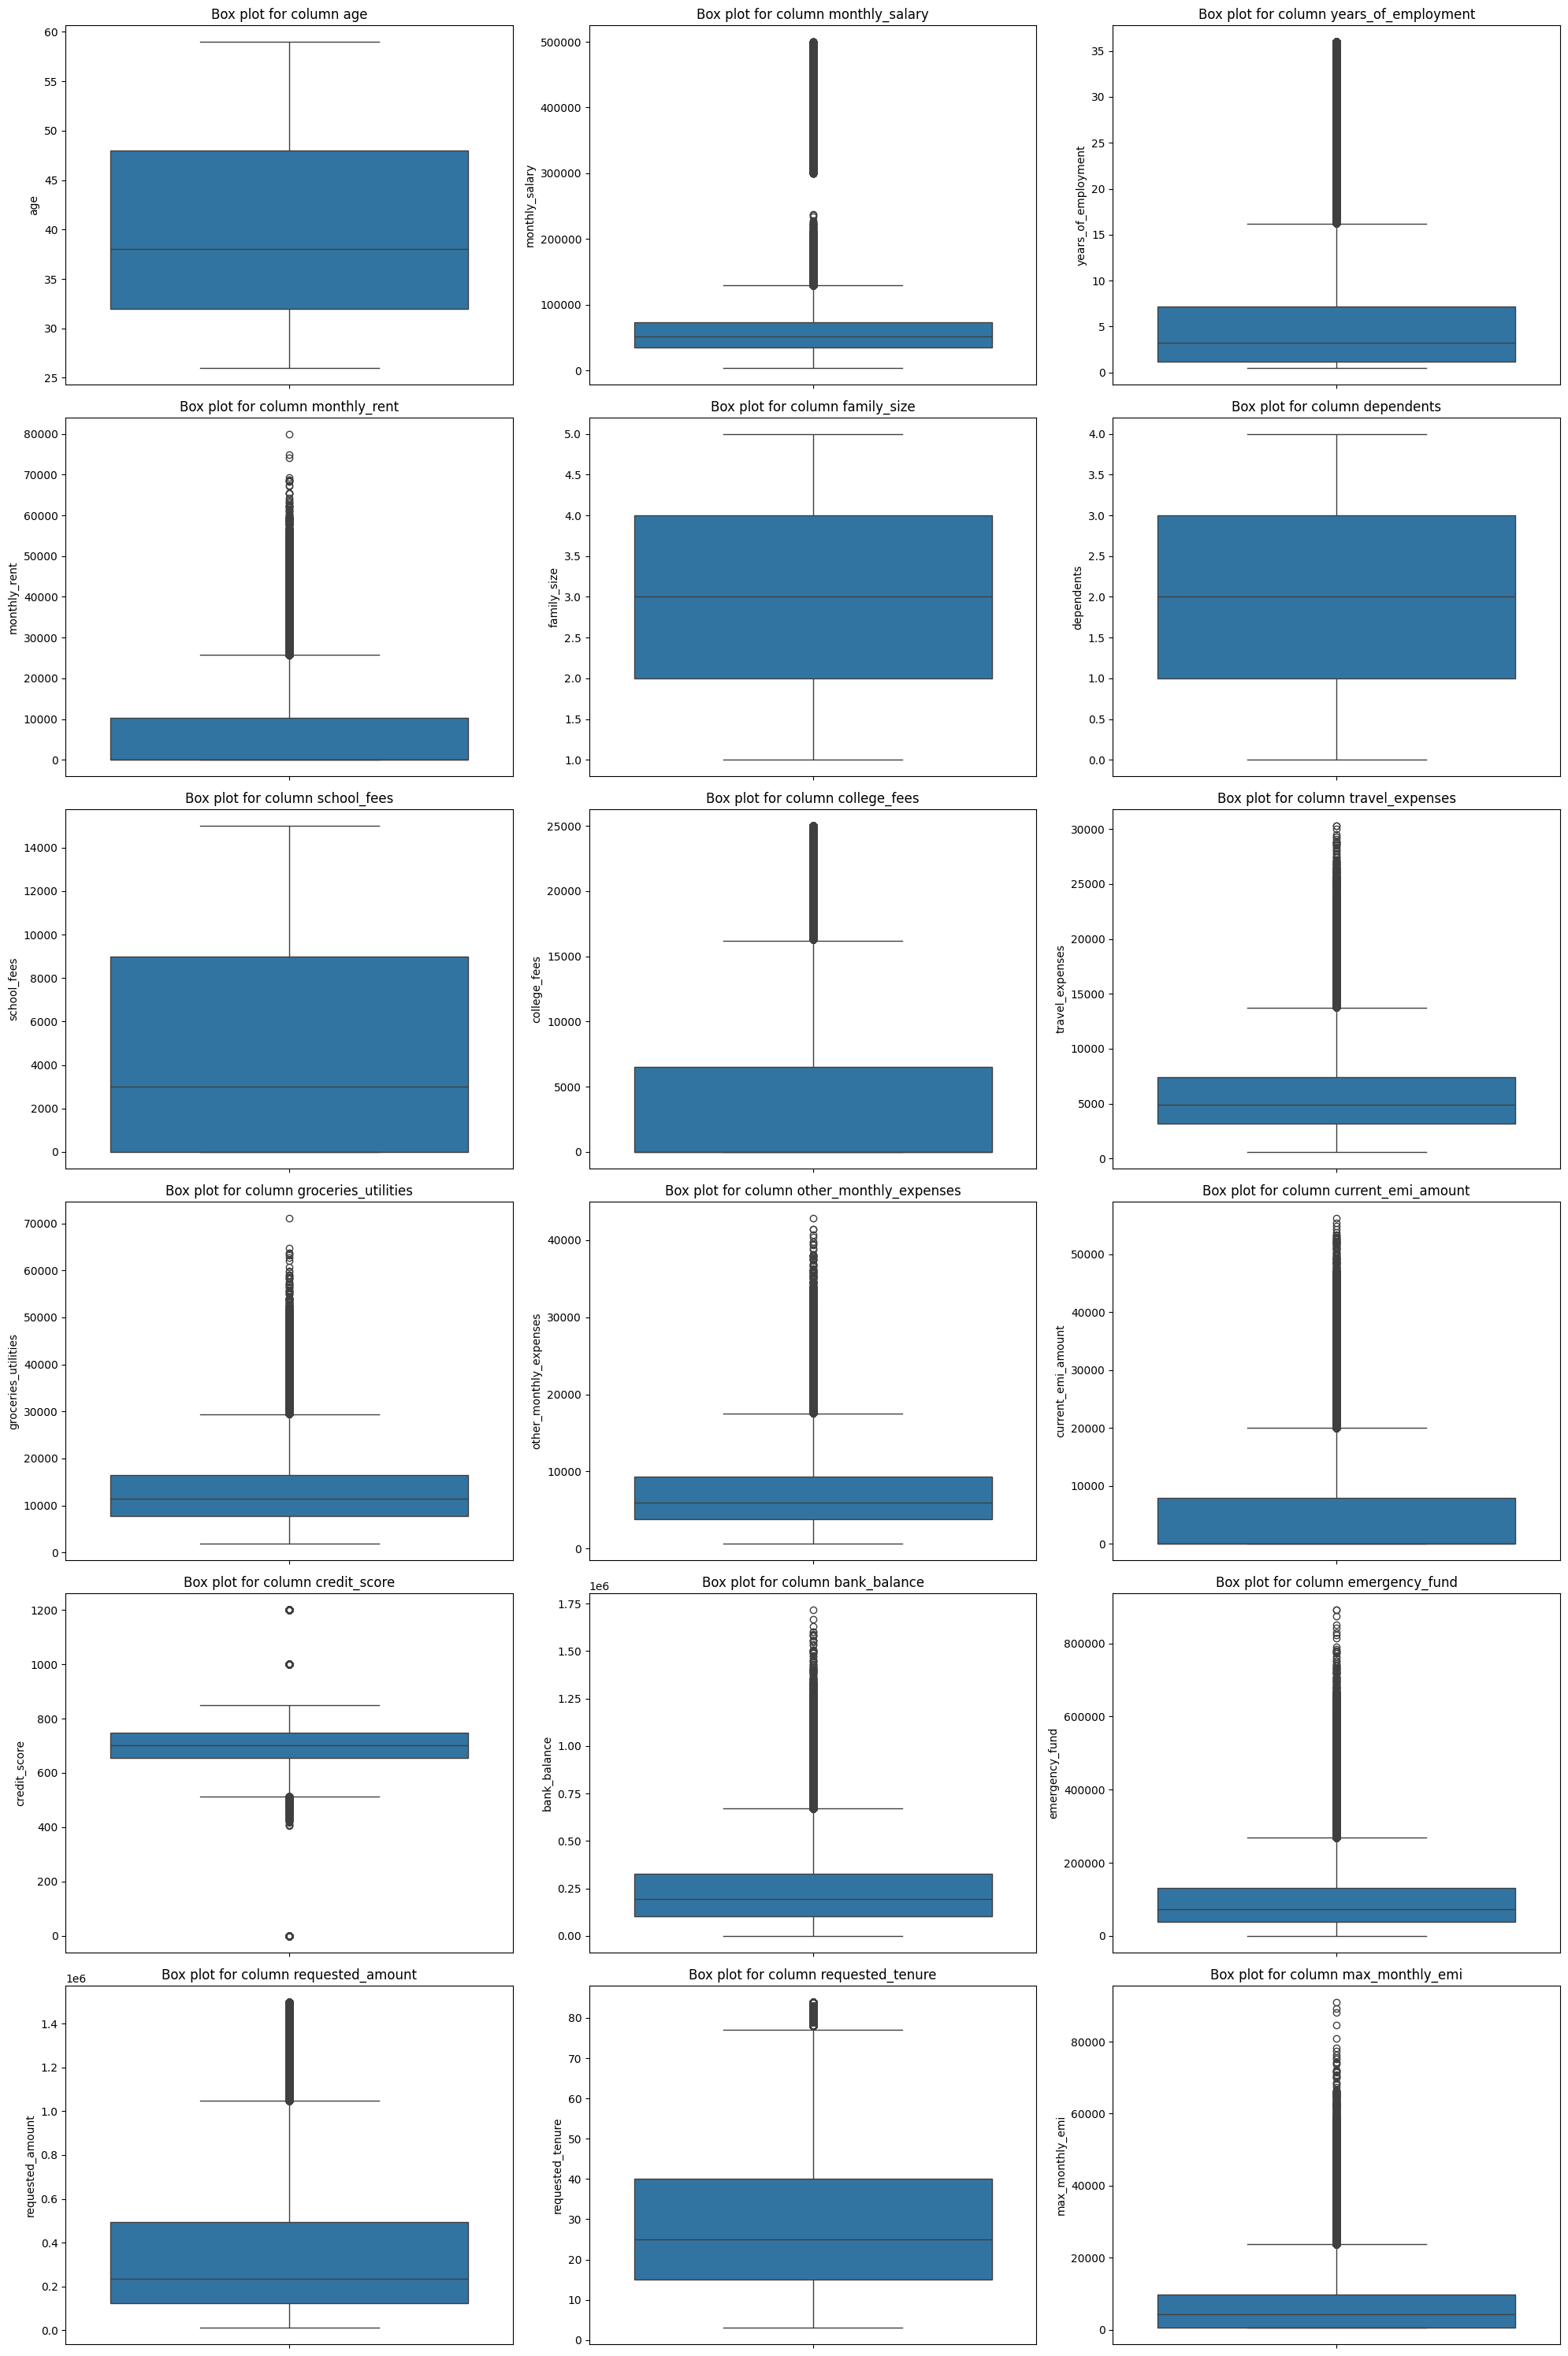

In [36]:
df_numeric = df.select_dtypes(exclude=['object']).columns
plt.figure(figsize=(20,30))
for i,col in enumerate(df_numeric):
    plt.subplot(6,3,i+1)
    sns.boxplot(y=df[col])
    plt.title(f"Box plot for column {col}")
    plt.ylabel(col)
    plt.tight_layout()


From above visulization with domain point of view , There are no potential outliers present in the most of the columns even though they show more values present in out of box range.

The credit score column seem to have outliers.
values that are below 300 and above 900 will have the same effect on the eligibility even if they has 300 or 900.
So we will correct only the outliers present in the credit score column alone and even the data points above the 900 points and below 300.
we will clip the value between 300 to 900.

Since outliers removal or treatment is of no use on other columns. we will check skewness and handle skewness by using transformation which can be best for linear regression and logicstic regression.


box plot after treating outliers on the credit_score colum


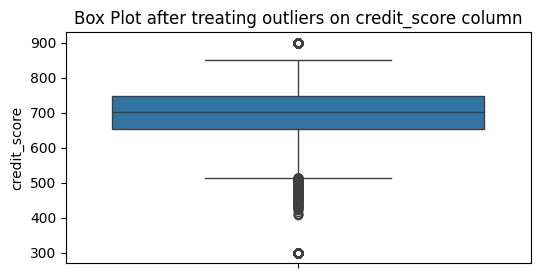

In [37]:
df['credit_score'] = df['credit_score'].clip(lower=300,upper=900)
print("box plot after treating outliers on the credit_score colum")
plt.figure(figsize=(6,3))
sns.boxplot(y=df['credit_score'])
plt.title("Box Plot after treating outliers on credit_score column")
plt.show()

**EMI eligibility Distribution Patterns**

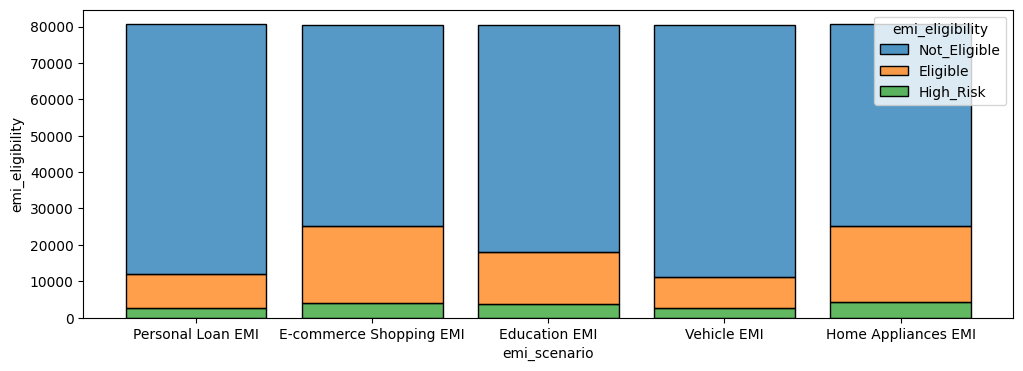

In [38]:
#To understand different eligibility distribution across different EMI scearios,

# We will plot stacked bar chart

plt.figure(figsize=(12,4))
sns.histplot(df,x='emi_scenario',hue='emi_eligibility',multiple='stack',shrink=0.8)
plt.ylabel('emi_eligibility')
plt.show()

From the above distribution pattern , We can understand that Not eligible is the largest in all lending scenario. This implies that there is a strict loan approval process.
E-commerce and Home appliances loans were largely approved than other loans.
It's because of low loan amount requested or less strict approval processes than other loans types.

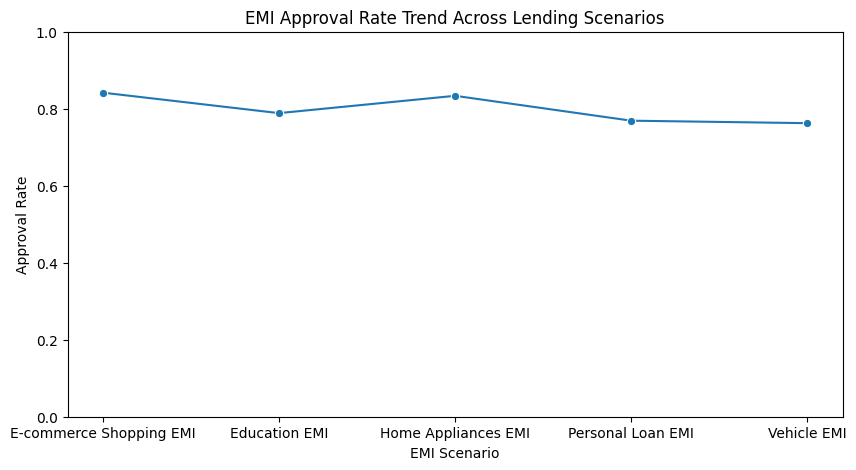

In [39]:
#Line Diagram to show the approval trend across emi scenarios.
approval_rate = (
    df.assign(
        approved=df['emi_eligibility'].map({
            'Eligible': 1,
            'High_Risk': 0,
            'Not Eligible': 0
        })
    )
    .groupby('emi_scenario')['approved']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,5))
sns.lineplot(
    data=approval_rate,
    x='emi_scenario',
    y='approved',
    marker='o'
)

plt.title("EMI Approval Rate Trend Across Lending Scenarios")
plt.ylabel("Approval Rate")
plt.xlabel("EMI Scenario")
plt.ylim(0,1)
plt.show()


The y-axis represents the approval rate, ranging from 0 to 1, and the x-axis lists the different EMI scenarios. This plot helps in understanding which lending scenarios tend to have higher or lower approval probabilities.

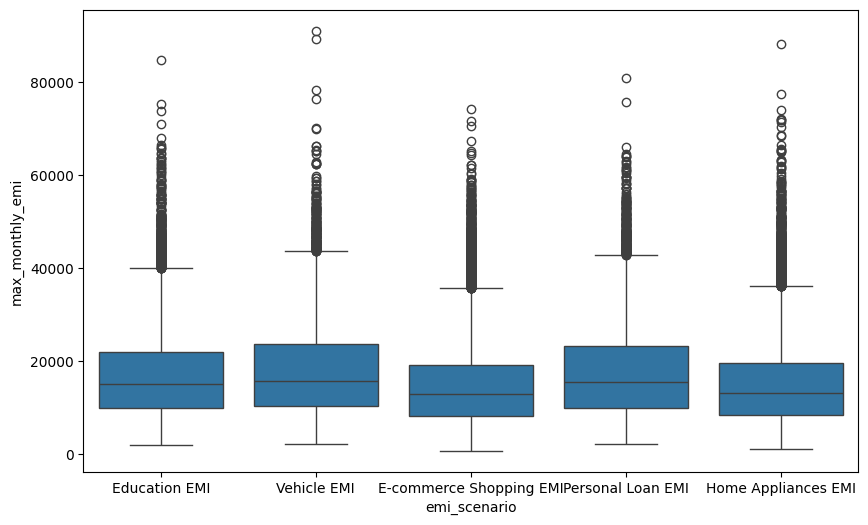

In [40]:
#Box plot to find out Max Monthly EMI for Approved Customers by Scenario

approved_df = df[df['emi_eligibility'] == 'Eligible']
plt.figure(figsize=(10,6))
sns.boxplot(data=approved_df,x='emi_scenario',y='max_monthly_emi')
plt.show()

This box plot illustrates the distribution of max_monthly_emi specifically for customers who were deemed 'Eligible', grouped by emi_scenario. It shows the median, quartiles, and potential outliers of the maximum monthly EMI that eligible customers can afford for each loan type. This helps in understanding the typical EMI ranges for approved applicants in various scenarios.

#Let's Understand the corrleation between the emi eligibity and the financial indicators

In [41]:
df_copy = df.copy()
print("unique values before applying mapping ....")
print(df_copy['emi_eligibility'].unique())
df_copy['emi_eligibility'] = df_copy['emi_eligibility'].map({'Eligible':2,'High_Risk':1,'Not_Eligible':0})
print("unique values in the emi eligibility after mapping...",df_copy['emi_eligibility'].unique())

unique values before applying mapping ....
['Not_Eligible' 'Eligible' 'High_Risk']
unique values in the emi eligibility after mapping... [0 2 1]


In [42]:
financial_variables = ['monthly_salary','monthly_rent','school_fees','college_fees','travel_expenses','groceries_utilities','other_monthly_expenses','current_emi_amount','credit_score','bank_balance','emergency_fund','requested_amount','requested_tenure','max_monthly_emi','emi_eligibility']
df_corrleation = df_copy[financial_variables].corr()
display(df_corrleation)

,monthly_salary,monthly_rent,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,current_emi_amount,credit_score,bank_balance,emergency_fund,requested_amount,requested_tenure,max_monthly_emi,emi_eligibility
monthly_salary,1.000000,0.208617,-0.003160,-0.001961,0.541826,0.593192,0.511151,0.206482,0.081328,0.419119,0.382233,-0.002089,-0.000095,0.379210,0.225252
monthly_rent,0.208617,1.000000,-0.003583,0.000730,0.273958,0.297684,0.254236,0.102199,0.040388,0.206068,0.187904,-0.001337,0.000486,-0.177117,-0.108554
school_fees,-0.003160,-0.003583,1.000000,0.054590,0.000643,-0.000121,0.000404,-0.001436,0.006656,-0.001078,-0.001904,0.001646,0.000106,-0.215261,-0.141269
college_fees,-0.001961,0.000730,0.054590,1.000000,-0.001734,-0.002358,-0.000230,0.000674,0.003815,-0.002470,-0.001982,0.003678,-0.001417,-0.258676,-0.169924
travel_expenses,0.541826,0.273958,0.000643,-0.001734,1.000000,0.772037,0.666224,0.270073,0.107272,0.545130,0.497718,-0.000417,-0.000557,0.440997,0.264149
groceries_utilities,0.593192,0.297684,-0.000121,-0.002358,0.772037,1.000000,0.726975,0.295556,0.117447,0.596524,0.543570,0.000564,-0.000054,0.484798,0.290191
other_monthly_expenses,0.511151,0.254236,0.000404,-0.000230,0.666224,0.726975,1.000000,0.254521,0.100904,0.515849,0.469344,-0.001699,-0.001050,0.382076,0.229092
current_emi_amount,0.206482,0.102199,-0.001436,0.000674,0.270073,0.295556,0.254521,1.000000,-0.162182,0.209473,0.190056,0.001249,-0.001736,-0.242438,-0.154547
credit_score,0.081328,0.040388,0.006656,0.003815,0.107272,0.117447,0.100904,-0.162182,1.000000,0.083092,0.075857,0.000250,0.000118,0.272513,0.169229
bank_balance,0.419119,0.206068,-0.001078,-0.002470,0.545130,0.596524,0.515849,0.209473,0.083092,1.000000,0.881834,0.000123,-0.001095,0.451812,0.262650


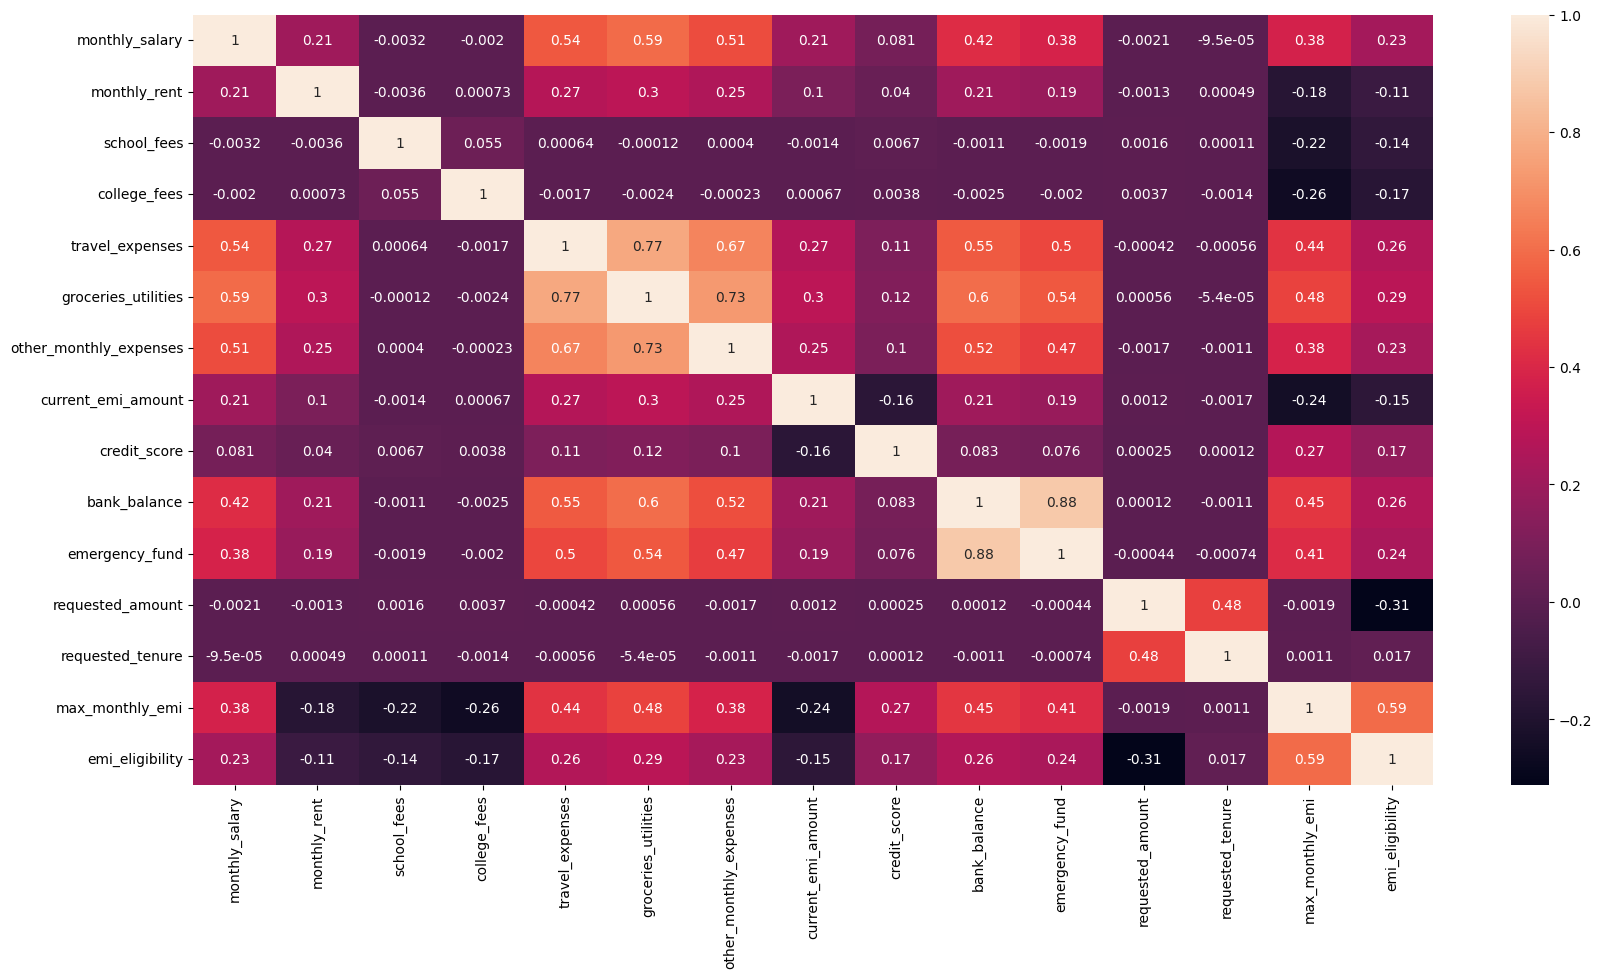

In [43]:
# let plot heat map to understand this in visual diagram
plt.figure(figsize=(20,10))
sns.heatmap(data=df_corrleation,annot=True)
plt.show()

**Observation**


In [44]:
print("### Correlation of 'emi_eligibility' with financial variables:\n")


# Get the correlations of 'emi_eligibility' with all other financial variables
emi_eligibility_correlations = df_corrleation['emi_eligibility'].drop('emi_eligibility')

# Iterate through and describe each correlation
for feature, correlation_value in emi_eligibility_correlations.items():
    direction = "positively" if correlation_value > 0 else "negatively"
    abs_correlation = abs(correlation_value)

    if abs_correlation >= 0.7:
        strength = "very strong"
    elif abs_correlation >= 0.5:
        strength = "strong"
    elif abs_correlation >= 0.3:
        strength = "moderate"
    elif abs_correlation >= 0.1:
        strength = "weak"
    else:
        strength = "very weak / negligible"

    print(f"- '{feature}' is {direction} {strength} correlated with 'emi_eligibility' (Correlation: {correlation_value:.2f})")



### Correlation of 'emi_eligibility' with financial variables:

- 'monthly_salary' is positively weak correlated with 'emi_eligibility' (Correlation: 0.23)
- 'monthly_rent' is negatively weak correlated with 'emi_eligibility' (Correlation: -0.11)
- 'school_fees' is negatively weak correlated with 'emi_eligibility' (Correlation: -0.14)
- 'college_fees' is negatively weak correlated with 'emi_eligibility' (Correlation: -0.17)
- 'travel_expenses' is positively weak correlated with 'emi_eligibility' (Correlation: 0.26)
- 'groceries_utilities' is positively weak correlated with 'emi_eligibility' (Correlation: 0.29)
- 'other_monthly_expenses' is positively weak correlated with 'emi_eligibility' (Correlation: 0.23)
- 'current_emi_amount' is negatively weak correlated with 'emi_eligibility' (Correlation: -0.15)
- 'credit_score' is positively weak correlated with 'emi_eligibility' (Correlation: 0.17)
- 'bank_balance' is positively weak correlated with 'emi_eligibility' (Correlation: 0.26)
- 'em

**Data Analysis Key Findings**

1. max_monthly_emi has a strong positive correlation (0.59) with emi_eligibility, indicating that a higher capacity for monthly EMI payments significantly increases eligibility.


2. requested_amount shows a moderate negative correlation (-0.31) with emi_eligibility, suggesting that a larger loan request moderately decreases the likelihood of EMI eligibility.


3. Several variables exhibit weak positive correlations with emi_eligibility, including groceries_utilities (0.29), travel_expenses (0.26), bank_balance (0.26), emergency_fund (0.24), monthly_salary (0.23), other_monthly_expenses (0.23), and credit_score (0.17). This implies that higher values in these areas are weakly associated with greater eligibility.


4. Variables with weak negative correlations include college_fees (-0.17), current_emi_amount (-0.15), school_fees (-0.14), and monthly_rent (-0.11).
Higher values in these expenses are weakly associated with lower EMI eligibility.


5. requested_tenure has a very weak/negligible positive correlation (0.02) with emi_eligibility, suggesting minimal impact on eligibility.:

EMI Eligibility by Gender:


emi_eligibility,Eligible,High_Risk,Not_Eligible,Total_Applicants,Approval_Percentage
gender,,,,,
FEMALE,29627,6953,124476,161056,18.395465
MALE,44455,10443,186850,241748,18.388984


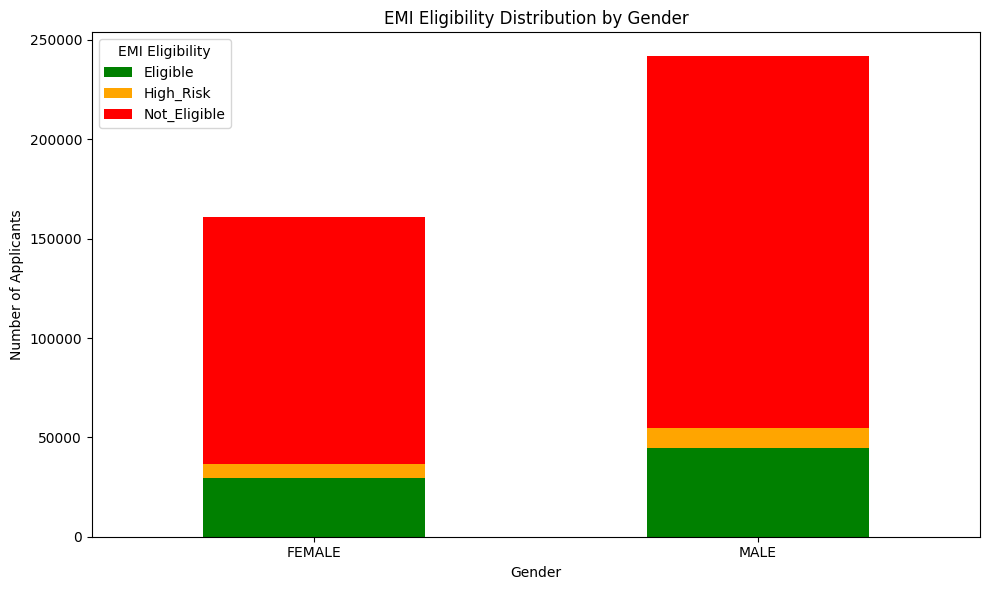

In [45]:
gender_eligibility_counts = df.groupby(['gender', 'emi_eligibility']).size().unstack(fill_value=0)
gender_eligibility_counts['Total_Applicants'] = gender_eligibility_counts.sum(axis=1)
gender_eligibility_counts['Approval_Percentage'] = (gender_eligibility_counts['Eligible'] / gender_eligibility_counts['Total_Applicants']) * 100
print("EMI Eligibility by Gender:")
display(gender_eligibility_counts)

# Plotting the stacked bar chart
gender_eligibility_counts[['Eligible', 'High_Risk', 'Not_Eligible']].plot(kind='bar', stacked=True, figsize=(10, 6), color=['green', 'orange', 'red'])
plt.title('EMI Eligibility Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=0)
plt.legend(title='EMI Eligibility')
plt.tight_layout()
plt.show()

# EMI Eligibility by Marital Status

EMI Eligibility by Marital Status:


emi_eligibility,Eligible,High_Risk,Not_Eligible,Total_Applicants,Approval_Percentage
marital_status,,,,,
Married,54164,12785,239393,306342,17.680893
Single,19918,4611,71933,96462,20.648546


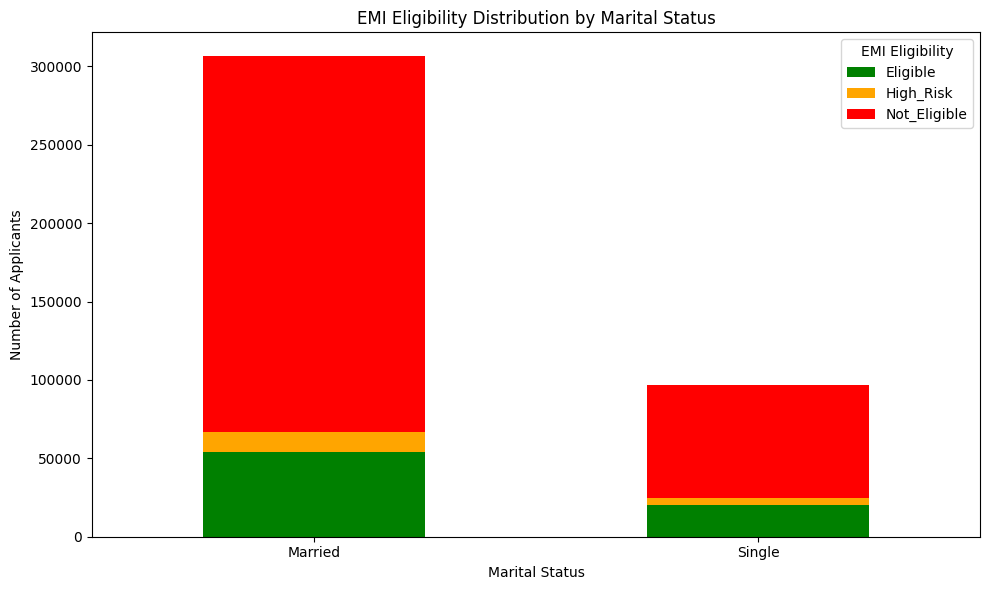

In [46]:
marital_status_eligibility_counts = df.groupby(['marital_status', 'emi_eligibility']).size().unstack(fill_value=0)
marital_status_eligibility_counts['Total_Applicants'] = marital_status_eligibility_counts.sum(axis=1)
marital_status_eligibility_counts['Approval_Percentage'] = (marital_status_eligibility_counts['Eligible'] / marital_status_eligibility_counts['Total_Applicants']) * 100
print("EMI Eligibility by Marital Status:")
display(marital_status_eligibility_counts)

# Plotting the stacked bar chart
marital_status_eligibility_counts[['Eligible', 'High_Risk', 'Not_Eligible']].plot(kind='bar', stacked=True, figsize=(10, 6), color=['green', 'orange', 'red'])
plt.title('EMI Eligibility Distribution by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=0)
plt.legend(title='EMI Eligibility')
plt.tight_layout()
plt.show()

##EMI Eligibility Distribution by Education Level

EMI Eligibility by Education Level:


emi_eligibility,Eligible,High_Risk,Not_Eligible,Total_Applicants,Approval_Percentage
education,,,,,
Graduate,28487,7328,145396,181211,15.720348
High School,6763,1978,52045,60786,11.125917
Post Graduate,22518,4912,73000,100430,22.421587
Professional,16314,3178,40885,60377,27.020223


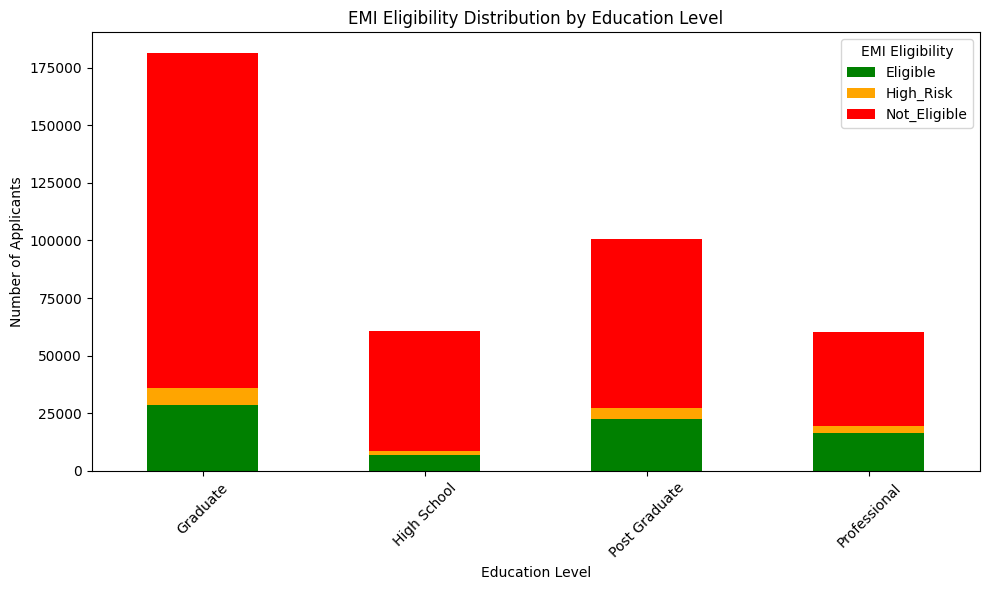

In [47]:
education_eligibility_counts = df.groupby(['education', 'emi_eligibility']).size().unstack(fill_value=0)
education_eligibility_counts['Total_Applicants'] = education_eligibility_counts.sum(axis=1)
education_eligibility_counts['Approval_Percentage'] = (education_eligibility_counts['Eligible'] / education_eligibility_counts['Total_Applicants']) * 100
print("EMI Eligibility by Education Level:")
display(education_eligibility_counts)

# Plotting the stacked bar chart
education_eligibility_counts[['Eligible', 'High_Risk', 'Not_Eligible']].plot(kind='bar', stacked=True, figsize=(10, 6), color=['green', 'orange', 'red'])
plt.title('EMI Eligibility Distribution by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=45)
plt.legend(title='EMI Eligibility')
plt.tight_layout()
plt.show()

##EMI Eligibility by Age Group:




EMI Eligibility by Age Group:


/tmp/ipython-input-2117782843.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_eligibility_counts = df.groupby(['age_group', 'emi_eligibility']).size().unstack(fill_value=0)


emi_eligibility,Eligible,High_Risk,Not_Eligible,Total_Applicants,Approval_Percentage
age_group,,,,,
<25,0,0,0,0,NaN
25-34,29729,6998,124004,160731,18.496121
35-44,22064,5096,93752,120912,18.247982
45-54,14838,3519,62248,80605,18.408287
55-64,7451,1783,31322,40556,18.372127
65+,0,0,0,0,NaN


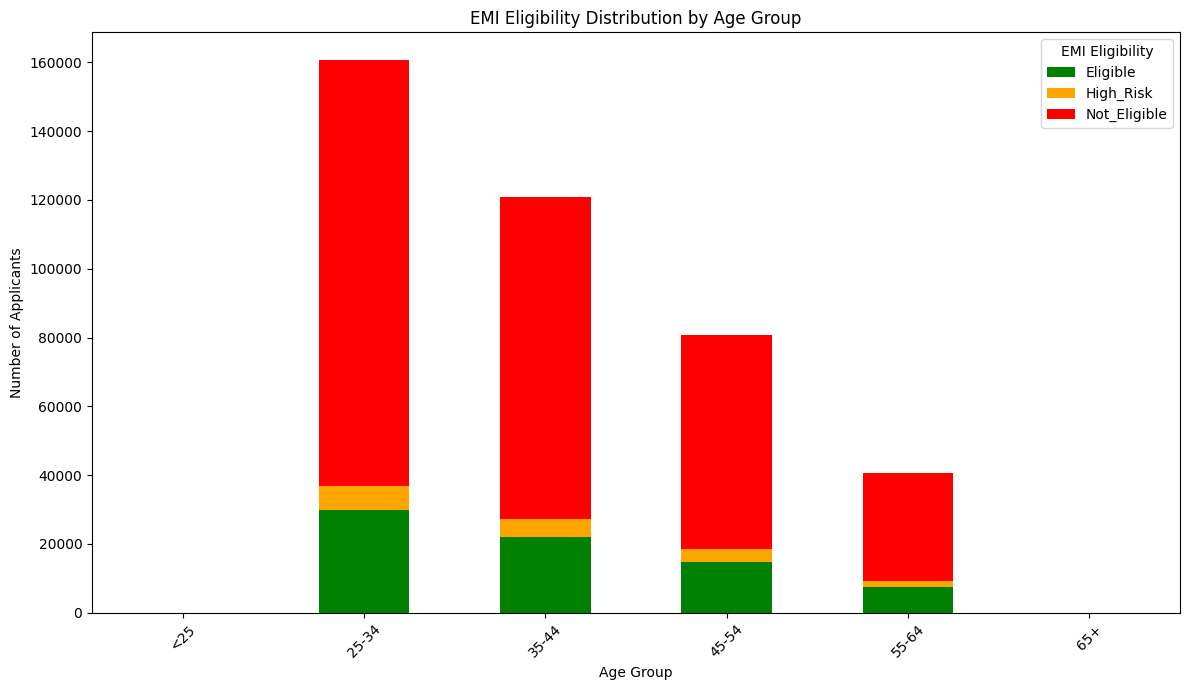

In [48]:
bins = [0, 25, 35, 45, 55, 65, np.inf]
labels = ['<25', '25-34', '35-44', '45-54', '55-64', '65+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

age_group_eligibility_counts = df.groupby(['age_group', 'emi_eligibility']).size().unstack(fill_value=0)
age_group_eligibility_counts['Total_Applicants'] = age_group_eligibility_counts.sum(axis=1)
age_group_eligibility_counts['Approval_Percentage'] = (age_group_eligibility_counts['Eligible'] / age_group_eligibility_counts['Total_Applicants']) * 100
print("EMI Eligibility by Age Group:")
display(age_group_eligibility_counts)

# Plotting the stacked bar chart
age_group_eligibility_counts[['Eligible', 'High_Risk', 'Not_Eligible']].plot(kind='bar', stacked=True, figsize=(12, 7), color=['green', 'orange', 'red'])
plt.title('EMI Eligibility Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=45)
plt.legend(title='EMI Eligibility')
plt.tight_layout()
plt.show()

##EMI Eligibility by House Type

EMI Eligibility by House Type:


emi_eligibility,Eligible,High_Risk,Not_Eligible,Total_Applicants,Approval_Percentage
house_type,,,,,
Family,24377,5390,70626,100393,24.281573
Own,34414,7599,99587,141600,24.303672
Rented,15291,4407,141113,160811,9.508678


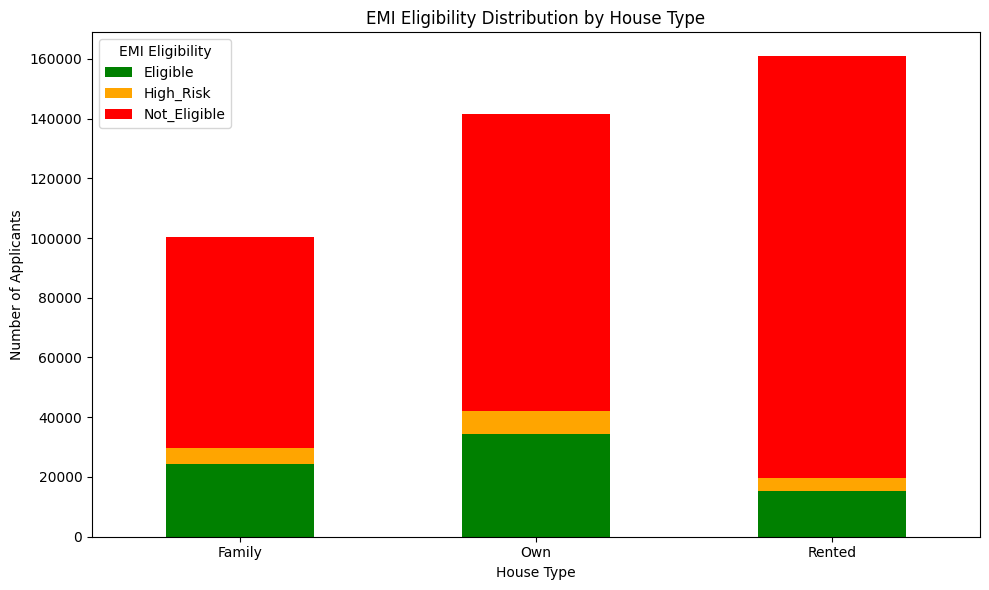

In [49]:
house_type_eligibility_counts = df.groupby(['house_type', 'emi_eligibility']).size().unstack(fill_value=0)
house_type_eligibility_counts['Total_Applicants'] = house_type_eligibility_counts.sum(axis=1)
house_type_eligibility_counts['Approval_Percentage'] = (house_type_eligibility_counts['Eligible'] / house_type_eligibility_counts['Total_Applicants']) * 100
print("EMI Eligibility by House Type:")
display(house_type_eligibility_counts)

# Plotting the stacked bar chart
house_type_eligibility_counts[['Eligible', 'High_Risk', 'Not_Eligible']].plot(kind='bar', stacked=True, figsize=(10, 6), color=['green', 'orange', 'red'])
plt.title('EMI Eligibility Distribution by House Type')
plt.xlabel('House Type')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=0)
plt.legend(title='EMI Eligibility')
plt.tight_layout()
plt.show()

## EMI Eligibility by Company Type

EMI Eligibility by Company Type:


emi_eligibility,Eligible,High_Risk,Not_Eligible,Total_Applicants,Approval_Percentage
company_type,,,,,
Large Indian,22345,5240,92965,120550,18.535877
MNC,18543,4392,77951,100886,18.380152
Mid-size,18424,4301,78095,100820,18.274152
Small,3680,859,15605,20144,18.268467
Startup,11090,2604,46710,60404,18.359711


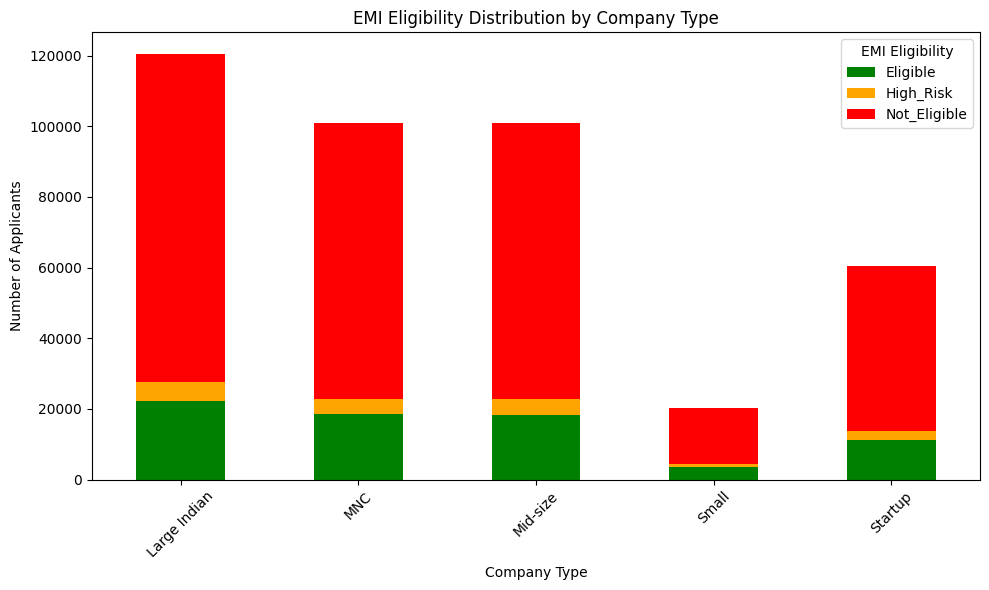

In [50]:
company_type_eligibility_counts = df.groupby(['company_type', 'emi_eligibility']).size().unstack(fill_value=0)
company_type_eligibility_counts['Total_Applicants'] = company_type_eligibility_counts.sum(axis=1)
company_type_eligibility_counts['Approval_Percentage'] = (company_type_eligibility_counts['Eligible'] / company_type_eligibility_counts['Total_Applicants']) * 100
print("EMI Eligibility by Company Type:")
display(company_type_eligibility_counts)

# Plotting the stacked bar chart
company_type_eligibility_counts[['Eligible', 'High_Risk', 'Not_Eligible']].plot(kind='bar', stacked=True, figsize=(10, 6), color=['green', 'orange', 'red'])
plt.title('EMI Eligibility Distribution by Company Type')
plt.xlabel('Company Type')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=45)
plt.legend(title='EMI Eligibility')
plt.tight_layout()
plt.show()


*   **Education Level**: Applicants with 'Professional' and 'Post Graduate' education backgrounds demonstrated notably higher approval rates compared to those with 'High School' or 'Graduate' qualifications.
*   **House Type**: Individuals living in 'Family' or 'Own' houses had significantly higher approval percentages than those living in 'Rented' houses.
*   **Marital Status**: Single applicants showed a moderately higher approval rate compared to married applicants.

Conversely, **Gender**, **Age Group** (within the active working range), and **Company Type** showed relatively little variation in EMI eligibility and approval rates, suggesting a less significant influence on loan decisions.

### Data Analysis Key Findings
*   **EMI Eligibility by Gender**: Female applicants had an approval percentage of approximately 18.40%, which was nearly identical to that of male applicants at approximately 18.39%.
*   **EMI Eligibility by Marital Status**: Single applicants exhibited a higher approval percentage of about 20.65%, compared to married applicants at approximately 17.68%.
*   **EMI Eligibility by Education Level**: Loan approval rates varied significantly by education: 'Professional' degree holders had the highest approval rate at approximately 27.01%, followed by 'Post Graduate' at around 22.45%. 'Graduate' applicants had an approval rate of about 15.71%, and 'High School' applicants had the lowest at approximately 11.13%.
*   **EMI Eligibility by Age Group**: Approval percentages were relatively consistent across the active age groups (25-64), ranging from approximately 18.25% to 18.50%. The '<25' and '65+' age groups had no applicants in the dataset.
*   **EMI Eligibility by House Type**: Applicants residing in 'Family' (~24.28%) and 'Own' (~24.30%) houses showed substantially higher approval percentages than those in 'Rented' houses, which had an approval rate of only about 9.51%.
*   **EMI Eligibility by Company Type**: Approval percentages were very similar across all company types ('Large Indian', 'MNC', 'Mid-size', 'Small', 'Startup'), ranging narrowly from approximately 18.27% to 18.54%.



# Task
Generate and display value counts and proportions for the following categorical columns in the DataFrame `df`: 'gender', 'marital_status', 'education', 'employment_type', 'company_type', 'house_type', 'existing_loans', 'emi_scenario', 'emi_eligibility', and 'age_group'.

## Generate Statistical Summaries for Categorical Columns

### Subtask:
Calculate and display value counts and proportions for key categorical columns to understand the distribution of categories.


In [51]:
categorical_columns = ['gender', 'marital_status', 'education', 'employment_type', 'company_type', 'house_type', 'existing_loans', 'emi_scenario', 'emi_eligibility', 'age_group']

for col in categorical_columns:
    print(f"\n--- Column: {col} ---")
    print("Value Counts:")
    print(df[col].value_counts())
    print("\nProportions:")
    print(df[col].value_counts(normalize=True))
    print("----------------------")


--- Column: gender ---
Value Counts:
gender
MALE      241748
FEMALE    161056
Name: count, dtype: int64

Proportions:
gender
MALE      0.600163
FEMALE    0.399837
Name: proportion, dtype: float64
----------------------

--- Column: marital_status ---
Value Counts:
marital_status
Married    306342
Single      96462
Name: count, dtype: int64

Proportions:
marital_status
Married    0.760524
Single     0.239476
Name: proportion, dtype: float64
----------------------

--- Column: education ---
Value Counts:
education
Graduate         181211
Post Graduate    100430
High School       60786
Professional      60377
Name: count, dtype: int64

Proportions:
education
Graduate         0.449874
Post Graduate    0.249327
High School      0.150907
Professional     0.149892
Name: proportion, dtype: float64
----------------------

--- Column: employment_type ---
Value Counts:
employment_type
Private          281687
Government        80810
Self-employed     40307
Name: count, dtype: int64

Proportions:


## Statistical Summaries


In [52]:
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns
descriptive_stats = df[numerical_columns].describe()
print("Descriptive Statistics for Numerical Columns:\n")
print(descriptive_stats)

Descriptive Statistics for Numerical Columns:

                 age  monthly_salary  years_of_employment   monthly_rent  \
count  402804.000000   402804.000000        402804.000000  402804.000000   
mean       38.876111    59509.352732             5.364576    5664.932547   
std         9.303279    43388.378570             6.079880    8585.502612   
min        26.000000     3967.000000             0.500000       0.000000   
25%        32.000000    35400.000000             1.200000       0.000000   
50%        38.000000    51700.000000             3.200000       0.000000   
75%        48.000000    73000.000000             7.200000   10300.000000   
max        59.000000   499970.000000            36.000000   80000.000000   

         family_size     dependents    school_fees   college_fees  \
count  402804.000000  402804.000000  402804.000000  402804.000000   
mean        2.940596       1.940596    4624.833418    4066.056444   
std         1.075265       1.075265    5061.195988    7318.98

## Business Insights from Statistical Summaries and Demographic Analyses

Based on the comprehensive data analysis, including statistical summaries for numerical and categorical columns, EMI eligibility distribution patterns, demographic analyses, and correlation analysis, the following actionable business insights have been identified:

### 1. Key Drivers of EMI Eligibility:

*   **`max_monthly_emi` (Strong Positive Correlation):** This is the strongest indicator of EMI eligibility (correlation: 0.59). Applicants with a higher capacity for monthly EMI payments are significantly more likely to be approved. This highlights the importance of assessing affordability accurately.
*   **Education Level:** 'Professional' (27.01% approval) and 'Post Graduate' (22.45% approval) degree holders show significantly higher approval rates than 'Graduate' (15.71%) and 'High School' (11.13%) applicants. This suggests that education is a strong proxy for financial stability and earning potential.
*   **House Type:** Applicants owning a house ('Own' ~24.30% approval) or living with family ('Family' ~24.28% approval) have substantially higher approval rates compared to those in 'Rented' houses (9.51% approval). This indicates that housing stability and lack of rent burden are crucial positive factors.
*   **Financial Indicators (Weak Positive Correlations):** Higher `monthly_salary` (0.23), `travel_expenses` (0.26), `groceries_utilities` (0.29), `other_monthly_expenses` (0.23), `bank_balance` (0.26), `emergency_fund` (0.24), and `credit_score` (0.17) are all weakly but positively correlated with eligibility. While individual impacts are small, collectively they contribute to a stronger financial profile.

### 2. Risk Factors:

*   **`requested_amount` (Moderate Negative Correlation):** A larger `requested_amount` (-0.31 correlation) moderately decreases the likelihood of EMI eligibility. This suggests that high loan values are a significant risk factor, leading to stricter approval criteria.
*   **High Monthly Expenses (Weak Negative Correlations):** Higher `college_fees` (-0.17), `current_emi_amount` (-0.15), `school_fees` (-0.14), and `monthly_rent` (-0.11) are weakly associated with lower EMI eligibility. These expenses reduce disposable income, impacting affordability.
*   **'Not_Eligible' Dominance:** The majority of applicants (77.29%) are 'Not_Eligible' across all EMI scenarios. This indicates a very conservative lending approach or a high proportion of applicants not meeting basic criteria. Specific scenarios like 'Personal Loan EMI' and 'Vehicle EMI' have lower approval rates compared to 'E-commerce Shopping EMI' and 'Home Appliances EMI', possibly due to higher requested amounts or perceived risk.
*   **Rented House Applicants:** This group has a significantly lower approval rate (~9.51%), marking them as a high-risk segment. Strategies might involve offering smaller loan amounts, higher interest rates, or requiring co-applicants for this group.

### 3. Demographic Insights with Minimal Impact:

*   **Gender:** EMI approval rates are nearly identical for 'FEMALE' (18.40%) and 'MALE' (18.39%) applicants, indicating gender neutrality in eligibility assessment.
*   **Age Group:** Approval percentages are relatively consistent across the active working age groups (25-64), ranging from 18.25% to 18.50%. This suggests that within this range, age itself is not a primary determinant of eligibility.
*   **Company Type:** Approval rates are very similar across all 'company_type' categories (18.27% to 18.54%). This implies that the specific type of company an applicant works for (e.g., MNC vs. Startup) has minimal influence on their EMI eligibility.
*   **`requested_tenure` (Negligible Correlation):** The correlation with `emi_eligibility` is almost zero (0.02), suggesting that the loan tenure requested has little to no direct impact on eligibility.


## Summary:

### Data Analysis Key Findings

*   **Demographics and Employment:** The dataset is predominantly male (approx. 60%), married (approx. 76%), and largely educated to 'Graduate' (approx. 45%) or 'Post Graduate' (approx. 25%) levels. The majority are employed in the 'Private' sector (approx. 70%), with 'Large Indian' companies being the most common employer type (approx. 29.9%). The largest age groups are '25-34' (approx. 39.9%) and '35-44' (approx. 30.0%).
*   **Housing and Existing Loans:** 'Rented' houses are the most common accommodation type (approx. 39.9%), followed by 'Own' (approx. 35.2%). A majority of individuals (approx. 60.1%) do not have existing loans.
*   **EMI Eligibility Distribution:** A significant majority of applicants (approx. 77.3%) are 'Not_Eligible' for EMI, while approx. 18.4% are 'Eligible' and approx. 4.3% are categorized as 'High_Risk'.
*   **Numerical Data Overview:** All numerical columns have a count of 402,804, indicating no missing values. Key metrics like `monthly_salary` show a wide spread (mean of ~59,509, std of ~43,388, max of 499,970), suggesting diverse financial backgrounds.
*   **Key Drivers of EMI Eligibility:**
    *   `max_monthly_emi` is the strongest positive predictor of eligibility, with a correlation of 0.59.
    *   Higher education ('Professional', 'Post Graduate') and stable housing ('Own' or 'Family') significantly increase approval rates compared to 'Rented' (9.51% approval) or 'High School' education (11.13% approval).
    *   Financial indicators such as `monthly_salary`, `bank_balance`, and `emergency_fund` show weak but positive correlations with eligibility.
*   **Key Risk Factors for EMI Eligibility:**
    *   A larger `requested_amount` has a moderate negative correlation of -0.31 with eligibility.
    *   High monthly expenses, including `college_fees`, `current_emi_amount`, `school_fees`, and `monthly_rent`, are weakly associated with lower eligibility.
*   **Factors with Minimal Impact on Eligibility:**
    *   Gender, age group (within active working ages), company type, and `requested_tenure` show negligible correlation or impact on EMI eligibility.
